# 📘 Simple Word2Vec Implementation with t-SNE Visualization

**Course:** MAI554 – Deep Learning  
**Topic:** Word Embeddings and Vector Representations

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand** the core idea behind Word2Vec — how words can be represented as dense numerical vectors.
2. **Implement** a simple Word2Vec model from scratch using PyTorch.
3. **Train** the model on a small text corpus and observe how the loss decreases over time.
4. **Extract** the learned word embeddings from the trained model.
5. **Visualize** high-dimensional embeddings in 2D using the t-SNE algorithm.
6. **Measure** word similarity using cosine similarity.
7. **Interpret** visualization results to understand semantic relationships captured by word embeddings.

---

### 💡 Key Concept: What is Word2Vec?

Word2Vec is a family of algorithms that learn **dense vector representations** (embeddings) for words from a text corpus. The fundamental insight is the **Distributional Hypothesis**:

> *"Words that appear in similar contexts tend to have similar meanings."*

For example, the words *"cat"* and *"dog"* often appear near words like *"pet"*, *"play"*, *"sleep"*, etc. Word2Vec uses this co-occurrence information to learn vectors where semantically similar words end up **close together** in the embedding space.

In this notebook, we implement a **Skip-gram**-style model: given a **center word**, the model tries to predict the **context words** (neighboring words) around it.

## Step 1: Import Required Libraries

We need the following libraries:
- **`torch`** — PyTorch, for building and training the neural network.
- **`numpy`** — for numerical operations on arrays.
- **`matplotlib`** — for plotting and visualization.
- **`sklearn.manifold.TSNE`** — for t-SNE dimensionality reduction.
- **`Counter`** from `collections` — to count word frequencies.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import Counter
import random
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

## Step 2: Define the Training Corpus

Below, we define **multiple text corpora** of varying lengths and styles. Each corpus contains sentences organized into three clear **semantic clusters**:

| Cluster | Example Words |
|---------|---------------|
| 🎨 **Colors** | red, blue, green, yellow |
| 🐾 **Animals** | cats, dogs, birds, lions |
| 👤 **People** | teacher, doctor, students |

The idea is that words within the same cluster frequently co-occur, while words across different clusters rarely appear together. After training, we expect the model to learn embeddings that **group these clusters**.

We provide several corpus variants (short, medium, long, relation-focused) to experiment with. The larger the corpus, the more training data the model has, which generally leads to better-quality embeddings.

In [ ]:
# Sample text with clear semantic clusters
text_short = """
the red color is bright and warm.
blue colors are cool and calming.
green leaves grow in spring.
yellow sun shines brightly.
red roses bloom in garden.
blue ocean waves crash.
green grass covers hills.

the cat sleeps peacefully.
dogs run and play fetch.
birds fly in the sky.
lions hunt their prey.
elephants walk slowly.
cats chase mice quickly.
dogs bark at mailman.

people walk in parks.
children play together.
teacher explains lesson.
doctor helps patients.
students learn math.
mother cooks dinner.
father reads stories.
"""

In [ ]:
# Sample text with focused semantic relationships
text_medium = """
red and blue colors paint the sunset sky.
yellow flowers bloom in green gardens.
green leaves dance in blue skies.
red birds soar through yellow light.
blue waters reflect green trees.
yellow sun warms the red earth.
green grass sways beneath blue clouds.

cats and dogs play in the yard.
birds watch while cats sleep quietly.
dogs chase after birds swiftly.
lions hunt while birds fly away.
cats hide when lions roar loudly.
dogs bark when lions approach.
birds warn cats of hunting lions.

teacher helps students learn math.
doctor treats sick students carefully.
students listen while teacher explains.
teacher shows doctor new methods.
students ask doctor many questions.
doctor assists teacher with health.
students respect teacher and doctor.
"""


In [ ]:
text_long="""
red and blue colors paint the sunset sky, blending into hues of purple.
yellow flowers bloom in green gardens, attracting red butterflies.
green leaves dance in blue skies, swaying with the soft yellow sunlight.
red birds soar through yellow light, their feathers shimmering like fire.
blue waters reflect green trees, creating a mirror of the natural world.
yellow sun warms the red earth, nurturing the green grass.
green grass sways beneath blue clouds, nourished by the yellow sun.
red roses grow beside yellow tulips in a field of green.
blue oceans meet yellow shores where red crabs scuttle.

cats and dogs play in the yard, chasing each other in circles.
birds watch while cats sleep quietly, perched on green branches.
dogs chase after birds swiftly, barking as their tails wag.
lions hunt while birds fly away, warning the smaller animals.
cats hide when lions roar loudly, seeking shelter in the shadows.
dogs bark when lions approach, standing their ground fearlessly.
birds warn cats of hunting lions, their chirps echoing through the trees.
cats stretch lazily under the warm sun while birds peck at scattered seeds.
dogs and cats sometimes fight but rest together under the same blue sky.

teacher helps students learn math, explaining with patience.
doctor treats sick students carefully, checking their health with concern.
students listen while teacher explains, absorbing every word.
teacher shows doctor new methods, improving both knowledge and care.
students ask doctor many questions, eager to understand science.
doctor assists teacher with health, ensuring students stay strong.
students respect teacher and doctor, valuing both wisdom and well-being.
teacher encourages students to explore, while doctor teaches them about the body.
students admire the doctor’s work, inspired to help others.
teacher and doctor share ideas, merging education with health.
"""

In [ ]:
text_relation="""
Red and blue sky.
Yellow flowers, green fields.
Green leaves, blue clouds.
Red birds, yellow light.
Blue water, green trees.
Yellow sun, red earth.
Green grass, blue wind.
Red roses, yellow tulips.
Blue ocean, yellow sand.
Green trees, blue air.

Cats, dogs play.
Birds watch cats sleep.
Dogs chase birds fast.
Lions hunt, birds fly.
Cats hide, lions roar.
Dogs bark, lions come.
Birds warn cats.
Cats stretch, birds eat.
Dogs, cats rest.
Lions walk, birds sing.

Teacher helps students.
Doctor checks students.
Students hear teacher.
Teacher shows doctor.
Students ask doctor.
Doctor teaches students.
Students respect teacher.
Teacher, doctor talk.
Students follow teacher.
Doctor guides students.
Teachers shape students.
"""

In [ ]:
text_relation_long="""
Red and blue sky.
Yellow flowers, green fields.
Green leaves, blue clouds.
Red birds, yellow light.
Blue water, green trees.
Yellow sun, red earth.
Green grass, blue wind.
Red roses, yellow tulips.
Blue ocean, yellow sand.
Green trees, blue air.
Yellow moon, red horizon.
Blue waves, green shore.
Red apples, yellow bananas.
Green vines, blue shadows.
Yellow butterflies, red petals.

Cats, dogs play.
Birds watch cats sleep.
Dogs chase birds fast.
Lions hunt, birds fly.
Cats hide, lions roar.
Dogs bark, lions come.
Birds warn cats.
Cats stretch, birds eat.
Dogs, cats rest.
Lions walk, birds sing.
Dogs guard, cats watch.
Birds circle, lions wait.
Cats climb, dogs jump.
Lions prowl, birds flee.
Dogs howl, cats hiss.

Teacher helps students.
Doctor checks students.
Students hear teacher.
Teacher shows doctor.
Students ask doctor.
Doctor teaches students.
Students respect teacher.
Teacher, doctor talk.
Students follow teacher.
Doctor guides students.
Teachers shape students.
Doctor heals, teacher explains.
Students learn, teacher leads.
Doctor listens, teacher instructs.
Students grow, doctor supports.
Teacher inspires, doctor advises.
"""

### Selecting the Corpus

We select `text_relation_long` as our training corpus. This variant has:
- **More sentences** per cluster (15-16 sentences per category).
- **Short, focused sentences** that emphasize direct word relationships (e.g., *"Dogs bark, lions come"*).

This structure helps the model learn stronger co-occurrence patterns, leading to clearer clustering in the final visualization.

In [ ]:
text=text_relation_long

### Quick Demo: Understanding Text Preprocessing

Before we define our preprocessing functions, let's see a quick example of how raw text is converted into a list of tokens (words):

1. **Lowercase** all characters (so "Teacher" and "teacher" are treated as the same word).
2. **Replace newlines** with spaces.
3. **Split** the text into individual words.

Run the cell below to see this in action.

In [ ]:
t = """Teacher inspires, doctor advises.
Students grow, doctor supports.
"""
print(t.lower())
print(t.lower().replace('\n', ' '))
print(t.lower().replace('\n', ' ').split())

teacher inspires, doctor advises.
students grow, doctor supports.

teacher inspires, doctor advises. students grow, doctor supports. 
['teacher', 'inspires,', 'doctor', 'advises.', 'students', 'grow,', 'doctor', 'supports.']


## Step 3: Text Preprocessing & Training Pair Generation

We define two key functions:

### `preprocess_text(text)`
This function:
1. Converts the entire text to **lowercase**.
2. Replaces newlines with spaces and **splits** into individual words.
3. Counts word frequencies using Python's `Counter`.
4. Creates two mapping dictionaries:
   - **`word2idx`**: maps each unique word → an integer index (e.g., `{'red': 0, 'blue': 2, ...}`).
   - **`idx2word`**: the reverse mapping, integer index → word.

### `generate_training_pairs(words, word2idx, window_size=1)`
This function creates **(center_word, context_word)** training pairs using a **sliding window**:

- For each word in the corpus (the *center word*), it looks at the words within `window_size` positions on either side (the *context words*).
- Each (center, context) pair becomes one training example.

**Example** with `window_size=1` and sentence *"cats dogs play"*:
- Center = "cats" → Context = ["dogs"] → Pair: (cats, dogs)
- Center = "dogs" → Context = ["cats", "play"] → Pairs: (dogs, cats), (dogs, play)
- Center = "play" → Context = ["dogs"] → Pair: (play, dogs)

In [ ]:
def preprocess_text(text):
    words = text.lower().replace('\n', ' ').split()
    word_counts = Counter(words)
    word2idx = {word: idx for idx, (word, _) in enumerate(word_counts.items())}
    idx2word = {idx: word for word, idx in word2idx.items()}
    return words, word2idx, idx2word

def generate_training_pairs(words, word2idx, window_size=1):
    pairs = []
    for i, center_word in enumerate(words):
        context_indices = list(range(max(0, i - window_size), i)) + \
                         list(range(i + 1, min(len(words), i + window_size + 1)))
        for j in context_indices:
            pairs.append((word2idx[center_word], word2idx[words[j]]))
    return pairs

## Step 4: Define the Word2Vec Neural Network

Our `SimpleWord2Vec` model is a small neural network with two layers:

```
Input (word index) → Embedding Layer → Linear (Output) Layer → Output (vocabulary scores)
```

1. **Embedding Layer** (`nn.Embedding`): A lookup table that maps each word index to a dense vector of size `embed_dim`. This is the layer whose weights **we want to learn** — these weights ARE the word embeddings.

2. **Output Layer** (`nn.Linear`): A fully connected layer that maps from the embedding space back to vocabulary size. It produces a score for each word in the vocabulary, predicting which context word is most likely.

During training, we use **CrossEntropyLoss** which combines a softmax operation and negative log-likelihood. The model learns to maximize the probability of the correct context word given a center word.

### How does this relate to real Word2Vec?
This is a simplified version of the **Skip-gram** architecture. In production Word2Vec, optimizations like **negative sampling** or **hierarchical softmax** are used to speed up training on large vocabularies.

### 🧠 Visual Architecture of Our Word2Vec Model

Below is a visual representation of the Skip-gram Word2Vec architecture using words from our corpus.

The idea is simple:
- The **input** is a one-hot encoded vector representing a word (e.g., "cats").
- The **hidden layer** (Embedding Layer) transforms it into a dense vector of size `embed_dim` (50).
- The **output layer** produces scores for every word in the vocabulary.
- **Softmax** converts these scores into probabilities.
- The model is trained to **maximize the probability of the actual context word**.

```mermaid
graph LR
    subgraph IN["INPUT (One-Hot) · vocab_size"]
        I1["red"]
        I2["blue"]
        I3["cats"]
        I4["dogs"]
        I5["..."]
    end

    W1["W₁<br/>(V × 50)"]

    subgraph HID["HIDDEN (Embedding) · dim=50"]
        H1((h₁))
        H2((h₂))
        H3(("..."))
        H4((h₅₀))
    end

    W2["W₂<br/>(50 × V)"]

    subgraph OUT["OUTPUT (Softmax) · vocab_size"]
        O1["P(red)"]
        O2["P(blue)"]
        O3["P(cats)"]
        O4["P(dogs)"]
        O5["P(...)"]
    end

    I1 & I2 & I3 & I4 & I5 --> W1 --> H1 & H2 & H3 & H4
    H1 & H2 & H3 & H4 --> W2 --> O1 & O2 & O3 & O4 & O5

    style I3 fill:#FFB74D,stroke:#F57C00,stroke-width:2px,color:#000
    style O4 fill:#81C784,stroke:#388E3C,stroke-width:2px,color:#000
    style W1 fill:#E3F2FD,stroke:#1565C0,stroke-width:2px,color:#000
    style W2 fill:#E3F2FD,stroke:#1565C0,stroke-width:2px,color:#000

    style I4 fill:#FFB74D,stroke:#F57C00,stroke-width:2px,color:#000
    style O5 fill:#81C784,stroke:#388E3C,stroke-width:2px,color:#000
```

**In this example:**
- 🟠 The **input word** is "cats" (orange = center word)
- 🟢 The **target output** is "dogs" (green = context word to predict)
- **W₁** (the embedding matrix) has shape `(vocab_size × embed_dim)` — **these are the word embeddings we want to learn!**
- **W₂** (the output weight matrix) has shape `(embed_dim × vocab_size)`

> **💡 Key Insight:** After training, the rows of the **W₁ matrix** (the embedding layer weights) become the word embedding vectors. Each row corresponds to one word's embedding. When we call `model.embeddings(word_idx)`, we are simply looking up the corresponding row in W₁.

In [ ]:
class SimpleWord2Vec(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(SimpleWord2Vec, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        self.output_layer = nn.Linear(embed_dim, vocab_size)

    def forward(self, inputs):
        embeds = self.embeddings(inputs)
        output = self.output_layer(embeds)
        return output

Here is a more detailed illustration of the network architecture

```mermaid
graph LR
    subgraph IN["INPUT (One-Hot) · vocab_size"]
        I1["red"]
        I2["blue"]
        I3["cats"]
        I4["dogs"]
        I5["..."]
    end

    subgraph HID["HIDDEN (Embedding) · dim=50"]
        H1((h₁))
        H2((h₂))
        H3(("..."))
        H4((h₅₀))
    end

    subgraph OUT["OUTPUT (Softmax) · vocab_size"]
        O1["P(red)"]
        O2["P(blue)"]
        O3["P(cats)"]
        O4["P(dogs)"]
        O5["P(...)"]
    end

    I1 & I2 & I3 & I4 & I5 -->|"W₁ (V×50)"| H1 & H2 & H3 & H4
    H1 & H2 & H3 & H4 -->|"W₂ (50×V)"| O1 & O2 & O3 & O4 & O5

    style I3 fill:#FFB74D,stroke:#F57C00,stroke-width:2px,color:#000
    style O4 fill:#81C784,stroke:#388E3C,stroke-width:2px,color:#000
```

## Step 5: Create the Model and Set Up Training

Here we:
1. **Preprocess** the text to get the word list, `word2idx`, and `idx2word`.
2. Set `embedding_dim = 50` — each word will be represented as a 50-dimensional vector. Higher dimensions can capture more nuance but require more data.
3. **Instantiate** the `SimpleWord2Vec` model.
4. Define the **loss function** (`CrossEntropyLoss`) and **optimizer** (`Adam` with `lr=0.01`).

In [ ]:
# Process text and create model
words, word2idx, idx2word = preprocess_text(text)
vocab_size = len(word2idx)
embedding_dim = 50  # Increased dimension for better visualization

model = SimpleWord2Vec(vocab_size, embedding_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

### 🔍 Understanding the Shapes — Where Do Word Embeddings Come From?

The code above reveals the **internal structure** of our Word2Vec model. Let's break it down:

| Step | Layer | Shape | What It Represents |
|------|-------|-------|--------------------|
| 1 | **Input** | `[1]` | A single word index (integer) |
| 2 | **Embedding Layer (W₁)** | `[vocab_size, embed_dim]` | The **lookup table** — each row is a word's embedding |
| 3 | **After Embedding** | `[1, embed_dim]` | The 50-dim vector for our input word — **this IS the word embedding!** |
| 4 | **Linear Layer (W₂)** | `[embed_dim, vocab_size]` | Maps embedding back to vocabulary scores |
| 5 | **After Softmax** | `[1, vocab_size]` | Probability distribution over all words |

### ❓ "Where do the word embeddings come from?"

This is one of the most common and important questions! Here's the answer:

1. **Before training**: The embedding layer weights (`W₁`) are initialized **randomly**. There is no meaning in these vectors yet.

2. **During training**: The model tries to predict context words from center words. To minimize the loss (prediction error), backpropagation **adjusts the weights** of both the embedding layer (`W₁`) and the output layer (`W₂`). This is where the magic happens — words that appear in similar contexts gradually get **similar embedding vectors** because similar adjustments are made to their rows in `W₁`.

3. **After training**: The embedding layer weights have been optimized. **Each row of `W₁` is now a meaningful vector representation of the corresponding word.** When we call `model.embeddings(word_idx)`, we're simply looking up row `word_idx` from the trained `W₁` matrix.

> **💡 In short**: Word embeddings are the **learned weights of the embedding layer**. They start random and become meaningful through training!

In [ ]:
# ===== Exploring the Model Architecture in Detail =====
print("=" * 60)
print("WORD2VEC MODEL ARCHITECTURE - Layer by Layer")
print("=" * 60)

print(f"\nVocabulary size: {vocab_size} unique words")
print(f"Embedding dimension: {embedding_dim}")

# Show model summary
print(f"\n--- Model Layers ---")
for name, param in model.named_parameters():
    print(f"  Layer: {name:25s} | Shape: {str(list(param.shape)):20s} | Parameters: {param.numel()}")

total_params = sum(p.numel() for p in model.parameters())
print(f"\n  Total trainable parameters: {total_params:,}")

# Simulate a forward pass to show shapes at each step
print(f"\n--- Forward Pass Shape Analysis ---")
sample_word = 'cats'
sample_idx = word2idx[sample_word]
input_tensor = torch.tensor([sample_idx])

print(f"  1. Input word: '{sample_word}' → Index: {sample_idx}")
print(f"  2. Input tensor shape:     {list(input_tensor.shape)}    (batch of 1 word index)")

# Step through the model manually
embedding_output = model.embeddings(input_tensor)
print(f"  3. After Embedding layer:  {list(embedding_output.shape)}  (1 word × {embedding_dim}-dim vector)")
print(f"     → This IS the word embedding for '{sample_word}'!")

linear_output = model.output_layer(embedding_output)
print(f"  4. After Linear layer:     {list(linear_output.shape)}  (1 word × {vocab_size} vocab scores)")

softmax_output = torch.softmax(linear_output, dim=1)
print(f"  5. After Softmax:          {list(softmax_output.shape)}  (probabilities over vocabulary)")

# Show top-5 predicted context words
top5_probs, top5_indices = torch.topk(softmax_output, 5)
print(f"\n  Top-5 predicted context words for '{sample_word}' (before training properly):")
for prob, idx in zip(top5_probs[0], top5_indices[0]):
    print(f"    '{idx2word[idx.item()]}' → probability: {prob.item():.4f}")

print("\n" + "=" * 60)
print("KEY TAKEAWAY: The Embedding layer (W₁) weights ARE the")
print("word embeddings. Each row = one word's dense vector.")
print("=" * 60)


### Inspecting the Vocabulary

Let's examine what our preprocessing produced:

- **`words`** — The full list of tokens in the corpus (including duplicates). This is the sequence the model trains on.
- **`word2idx`** — A dictionary mapping each unique word to a unique integer ID.
- **`idx2word`** — The reverse mapping, from integer ID back to the word.

Notice that punctuation is **attached** to words (e.g., `"sky."`, `"cats,"`). In production systems, you would typically remove punctuation or use a proper tokenizer. Here, the punctuation actually creates distinct tokens, which is fine for our demonstration.

In [ ]:
print(words)

['red', 'and', 'blue', 'sky.', 'yellow', 'flowers,', 'green', 'fields.', 'green', 'leaves,', 'blue', 'clouds.', 'red', 'birds,', 'yellow', 'light.', 'blue', 'water,', 'green', 'trees.', 'yellow', 'sun,', 'red', 'earth.', 'green', 'grass,', 'blue', 'wind.', 'red', 'roses,', 'yellow', 'tulips.', 'blue', 'ocean,', 'yellow', 'sand.', 'green', 'trees,', 'blue', 'air.', 'yellow', 'moon,', 'red', 'horizon.', 'blue', 'waves,', 'green', 'shore.', 'red', 'apples,', 'yellow', 'bananas.', 'green', 'vines,', 'blue', 'shadows.', 'yellow', 'butterflies,', 'red', 'petals.', 'cats,', 'dogs', 'play.', 'birds', 'watch', 'cats', 'sleep.', 'dogs', 'chase', 'birds', 'fast.', 'lions', 'hunt,', 'birds', 'fly.', 'cats', 'hide,', 'lions', 'roar.', 'dogs', 'bark,', 'lions', 'come.', 'birds', 'warn', 'cats.', 'cats', 'stretch,', 'birds', 'eat.', 'dogs,', 'cats', 'rest.', 'lions', 'walk,', 'birds', 'sing.', 'dogs', 'guard,', 'cats', 'watch.', 'birds', 'circle,', 'lions', 'wait.', 'cats', 'climb,', 'dogs', 'jump.',

In [ ]:
print(word2idx)

{'red': 0, 'and': 1, 'blue': 2, 'sky.': 3, 'yellow': 4, 'flowers,': 5, 'green': 6, 'fields.': 7, 'leaves,': 8, 'clouds.': 9, 'birds,': 10, 'light.': 11, 'water,': 12, 'trees.': 13, 'sun,': 14, 'earth.': 15, 'grass,': 16, 'wind.': 17, 'roses,': 18, 'tulips.': 19, 'ocean,': 20, 'sand.': 21, 'trees,': 22, 'air.': 23, 'moon,': 24, 'horizon.': 25, 'waves,': 26, 'shore.': 27, 'apples,': 28, 'bananas.': 29, 'vines,': 30, 'shadows.': 31, 'butterflies,': 32, 'petals.': 33, 'cats,': 34, 'dogs': 35, 'play.': 36, 'birds': 37, 'watch': 38, 'cats': 39, 'sleep.': 40, 'chase': 41, 'fast.': 42, 'lions': 43, 'hunt,': 44, 'fly.': 45, 'hide,': 46, 'roar.': 47, 'bark,': 48, 'come.': 49, 'warn': 50, 'cats.': 51, 'stretch,': 52, 'eat.': 53, 'dogs,': 54, 'rest.': 55, 'walk,': 56, 'sing.': 57, 'guard,': 58, 'watch.': 59, 'circle,': 60, 'wait.': 61, 'climb,': 62, 'jump.': 63, 'prowl,': 64, 'flee.': 65, 'howl,': 66, 'hiss.': 67, 'teacher': 68, 'helps': 69, 'students.': 70, 'doctor': 71, 'checks': 72, 'students':

In [ ]:
print(idx2word)

{0: 'red', 1: 'and', 2: 'blue', 3: 'sky.', 4: 'yellow', 5: 'flowers,', 6: 'green', 7: 'fields.', 8: 'leaves,', 9: 'clouds.', 10: 'birds,', 11: 'light.', 12: 'water,', 13: 'trees.', 14: 'sun,', 15: 'earth.', 16: 'grass,', 17: 'wind.', 18: 'roses,', 19: 'tulips.', 20: 'ocean,', 21: 'sand.', 22: 'trees,', 23: 'air.', 24: 'moon,', 25: 'horizon.', 26: 'waves,', 27: 'shore.', 28: 'apples,', 29: 'bananas.', 30: 'vines,', 31: 'shadows.', 32: 'butterflies,', 33: 'petals.', 34: 'cats,', 35: 'dogs', 36: 'play.', 37: 'birds', 38: 'watch', 39: 'cats', 40: 'sleep.', 41: 'chase', 42: 'fast.', 43: 'lions', 44: 'hunt,', 45: 'fly.', 46: 'hide,', 47: 'roar.', 48: 'bark,', 49: 'come.', 50: 'warn', 51: 'cats.', 52: 'stretch,', 53: 'eat.', 54: 'dogs,', 55: 'rest.', 56: 'walk,', 57: 'sing.', 58: 'guard,', 59: 'watch.', 60: 'circle,', 61: 'wait.', 62: 'climb,', 63: 'jump.', 64: 'prowl,', 65: 'flee.', 66: 'howl,', 67: 'hiss.', 68: 'teacher', 69: 'helps', 70: 'students.', 71: 'doctor', 72: 'checks', 73: 'studen

## Step 6: Check GPU Availability

Deep learning models train much faster on a **GPU** (Graphics Processing Unit). PyTorch can automatically detect if a CUDA-compatible GPU is available.

- If a GPU is available, the output will show: `Using device: cuda`
- Otherwise, it will show: `Using device: cpu`

For this small model and dataset, CPU is perfectly fine. GPUs become essential when training on large datasets with millions of words.

In [ ]:
#3. Working with GPU (if available)
print("\n=== GPU Operations ===")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


=== GPU Operations ===
Using device: cuda


## Step 7: Train the Word2Vec Model

Now we train the model for **1000 epochs**. Here's what happens in each epoch:

1. **Shuffle** the training pairs randomly (to avoid learning order-dependent patterns).
2. **Iterate** through mini-batches of size 8.
3. For each batch:
   - **Forward pass**: Feed center word indices through the model to get predictions.
   - **Compute loss**: Compare predictions against actual context word indices using `CrossEntropyLoss`.
   - **Backward pass**: Compute gradients using `loss.backward()`.
   - **Update weights**: Apply gradients using the Adam optimizer.
4. Every 100 epochs, print the **average loss** to monitor training progress.

### What to look for:
- The loss should **generally decrease** over time, indicating the model is learning.
- The loss may not decrease monotonically — small fluctuations are normal.

In [ ]:
# Training
print("Training Word2Vec model...")
n_epochs = 1000
batch_size = 8
training_pairs = generate_training_pairs(words, word2idx)

for epoch in range(n_epochs):
    total_loss = 0
    random.shuffle(training_pairs)

    for i in range(0, len(training_pairs), batch_size):
        batch = training_pairs[i:i + batch_size]
        input_words = torch.tensor([pair[0] for pair in batch])
        target_words = torch.tensor([pair[1] for pair in batch])



        outputs = model(input_words)
        loss = criterion(outputs, target_words)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1}, Loss: {total_loss/len(training_pairs):.4f}')

Training Word2Vec model...
Epoch 100, Loss: 0.2425
Epoch 200, Loss: 0.2364
Epoch 300, Loss: 0.2317
Epoch 400, Loss: 0.2323
Epoch 500, Loss: 0.2282
Epoch 600, Loss: 0.2265
Epoch 700, Loss: 0.2261
Epoch 800, Loss: 0.2210
Epoch 900, Loss: 0.2257
Epoch 1000, Loss: 0.2213


### 📊 Interpreting the Training Results

Looking at the loss values printed above:

- The loss **decreases** from the first epoch to the last, which confirms the model is **learning** to predict context words from center words.
- The rate of decrease slows down over time — this is typical. Early epochs make large improvements, while later epochs make smaller refinements.
- The final loss value indicates how well the model can predict context words. Lower is better, but on a small corpus like ours, the loss may not drop very low because the vocabulary is diverse relative to the amount of data.

**Key insight**: As the model learns to predict context words accurately, the embedding vectors for words that share similar contexts become **more similar to each other** — this is exactly what we want!

In [ ]:
# Get embeddings for visualization
def get_word_embedding(word):
    idx = torch.tensor([word2idx[word]])
    return model.embeddings(idx).detach().numpy().flatten()

## Step 8: Extract Word Embeddings

After training, the word embeddings are stored in the **embedding layer** of our model (`model.embeddings`).

The function `get_word_embedding(word)` does the following:
1. Looks up the word's integer index using `word2idx`.
2. Passes this index through the embedding layer.
3. Returns the resulting 50-dimensional vector as a NumPy array.

Each word is now represented as a vector of 50 real numbers. Words with similar meanings should have **similar vectors**.

## Step 9: Define Word Clusters for Visualization

To visualize and evaluate our embeddings, we select a few representative words from each semantic category:

- 🎨 **Colors**: red, blue, green, yellow
- 🐾 **Animals**: cats, dogs, birds, lions
- 👤 **People**: teacher, students, doctor

We'll extract the embedding vectors for these 11 words and see if the model has learned to **group them by category**.

In [ ]:
# Define word clusters for visualization
color_words = ['red', 'blue', 'green', 'yellow']
animal_words = ['cats', 'dogs', 'birds', 'lions']
human_words = ['teacher', 'students', 'doctor']

In [ ]:
# Get embeddings for each cluster
colors_embeddings = [get_word_embedding(w) for w in color_words]
animals_embeddings = [get_word_embedding(w) for w in animal_words]
humans_embeddings = [get_word_embedding(w) for w in human_words]


### Viewing Raw Embedding Vectors

Below you can see the raw 50-dimensional embedding vectors for the color words. Each array contains 50 floating-point numbers — this is how a neural network "sees" a word.

These numbers are difficult to interpret directly, which is why we use **dimensionality reduction** techniques like t-SNE to project them into 2D for visualization.

In [ ]:
colors_embeddings

[array([ 3.02135479e-03, -6.63593598e-03,  1.16828782e-03,  1.02745311e-03,
         2.39743702e-02,  1.50174052e-02,  1.70376793e-01,  4.98538464e-03,
         5.15516818e-01,  1.84905659e-02, -3.00638396e-02,  3.03126057e-03,
        -7.90486019e-03, -1.03667545e+00,  1.00684976e-02, -4.44862209e-02,
        -1.82929635e+00, -3.11131738e-02,  3.60149704e-02, -4.35539754e-03,
         7.30440952e-03,  4.36596479e-03, -2.28022374e-02, -4.95357811e-03,
        -2.04256903e-02,  4.81155515e-03,  2.53263339e-02,  3.97135224e-03,
        -1.50119029e-02,  6.95028948e-03,  1.61544997e-02, -1.01760197e-02,
        -1.05820852e-03, -2.83339387e-03,  1.31049124e-03,  1.64493918e-02,
         5.60591323e-03, -4.75194771e-03,  8.02628114e-04,  2.41013356e-02,
        -2.10959241e-02, -2.41836384e-01, -1.28392512e-02,  4.14580805e-04,
        -1.47564672e-02,  1.98382903e-02, -8.78756959e-03, -1.20342905e-02,
         2.07775291e-02, -8.69054906e-03], dtype=float32),
 array([ 2.65856530e-03, -4.3

## Step 10: Visualize Embeddings with t-SNE

### What is t-SNE?

**t-SNE** (t-distributed Stochastic Neighbor Embedding) is a popular algorithm for visualizing high-dimensional data in 2D or 3D. It works by:

1. Computing **pairwise similarities** between points in the original high-dimensional space (50D in our case).
2. Creating a 2D map where the pairwise similarities are **preserved as much as possible**.
3. Points that are close in 50D should remain close in 2D, and points that are far apart should remain far apart.

### Key Parameters:
| Parameter | Value | Meaning |
|-----------|-------|---------|
| `n_components` | 2 | Reduce to 2 dimensions for plotting |
| `perplexity` | 5 | Controls the balance between local and global structure. Lower values (like 5) work better for small datasets. |
| `n_iter` | 1000 | Number of optimization iterations — more iterations give better convergence. |
| `learning_rate` | 100 | Step size for the optimization. |
| `random_state` | 42 | Fixed seed for reproducibility. |

First, we combine all embeddings and then apply t-SNE to reduce them from 50D to 2D.

In [ ]:
# Combine all embeddings and words for t-SNE
all_words = color_words + animal_words + human_words
all_embeddings = np.vstack(colors_embeddings + animals_embeddings + humans_embeddings)

In [ ]:
# Apply t-SNE with adjusted parameters for small dataset
tsne = TSNE(n_components=2,          # 2D visualization
            perplexity=5,            # Lower perplexity for small dataset
            n_iter=1000,             # More iterations for better convergence
            learning_rate=100,        # Adjusted learning rate
            random_state=42)         # For reproducibility
embeddings_2d = tsne.fit_transform(all_embeddings)


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


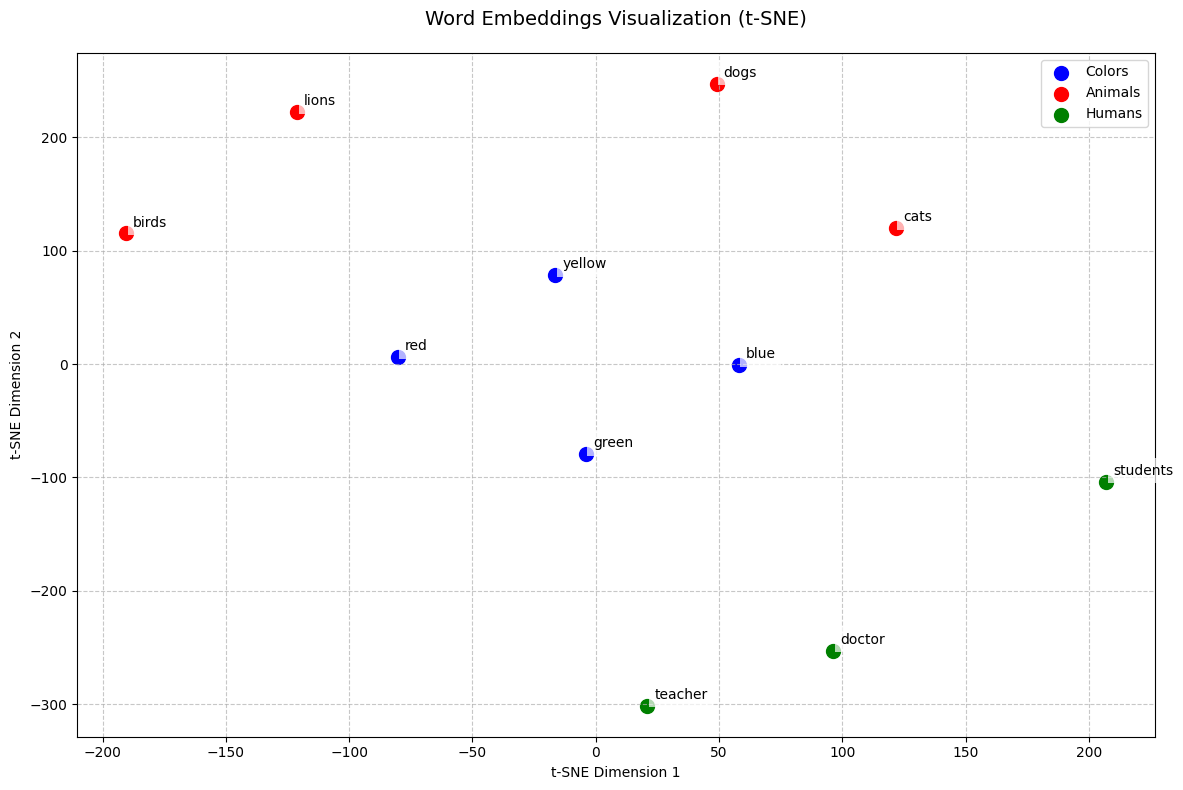

In [ ]:
# Create visualization
plt.figure(figsize=(12, 8))

# Plot each cluster with different colors and larger points
plt.scatter(embeddings_2d[:len(color_words), 0], embeddings_2d[:len(color_words), 1],
           c='blue', label='Colors', s=100)
plt.scatter(embeddings_2d[len(color_words):len(color_words)+len(animal_words), 0],
           embeddings_2d[len(color_words):len(color_words)+len(animal_words), 1],
           c='red', label='Animals', s=100)
plt.scatter(embeddings_2d[len(color_words)+len(animal_words):, 0],
           embeddings_2d[len(color_words)+len(animal_words):, 1],
           c='green', label='Humans', s=100)

# Add word labels with offset for better readability
for i, word in enumerate(all_words):
    plt.annotate(word,
                (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=10,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
plt.title('Word Embeddings Visualization (t-SNE)', fontsize=14, pad=20)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

# Add axis labels
plt.xlabel('t-SNE Dimension 1', fontsize=10)
plt.ylabel('t-SNE Dimension 2', fontsize=10)

plt.tight_layout()
plt.show()


### 📊 Interpreting the t-SNE Visualization

Look at the scatter plot above. Each dot represents a word, colored by its semantic category:
- 🔵 **Blue dots** = Color words (red, blue, green, yellow)
- 🔴 **Red dots** = Animal words (cats, dogs, birds, lions)
- 🟢 **Green dots** = Human/People words (teacher, students, doctor)

**What to observe:**
1. **Clustering**: Words from the same semantic category should be located **near each other**. If you see the colors grouped together, the animals grouped together, and the people grouped together, it means the model has successfully learned meaningful embeddings.

2. **Separation**: Different categories should appear in **different regions** of the plot, indicating the model distinguishes between color concepts, animal concepts, and human concepts.

3. **Imperfections**: Since we're working with a very small corpus, the clustering may not be perfect. With more data and fine-tuning, the clusters would become tighter and more distinct.

> **Note**: t-SNE is a stochastic algorithm — running it multiple times may produce different-looking plots, but the **relative structure** (which words are close vs. far) should be consistent.

## Step 11: Measure Word Similarity with Cosine Similarity

### What is Cosine Similarity?

Cosine similarity measures the **angle** between two vectors, ignoring their magnitude. It's defined as:

$$\text{cosine\_similarity}(\vec{v_1}, \vec{v_2}) = \frac{\vec{v_1} \cdot \vec{v_2}}{\|\vec{v_1}\| \times \|\vec{v_2}\|}$$

- **1.0** = vectors point in the exact same direction (identical meaning)
- **0.0** = vectors are perpendicular (unrelated)
- **-1.0** = vectors point in opposite directions (opposite meaning)

In practice, for word embeddings:
- **High similarity (close to 1)** → words are semantically similar
- **Low or negative similarity** → words are semantically different

In [ ]:
# Function to calculate similarity between word embeddings
def cosine_similarity(v1, v2):
    """
    Calculate cosine similarity between two vectors.
    Cosine similarity = dot product of vectors / (norm of v1 * norm of v2)
    Range is -1 (opposite) to 1 (identical).
    """
    # Calculate dot product
    dot_product = np.dot(v1, v2)
    # Calculate norms
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    # Calculate cosine similarity
    return dot_product / (norm_v1 * norm_v2)

In [ ]:
# Print some example similarities
print("\nExample similarities within and across clusters:")
# Within clusters
print("\nWithin Clusters:")
print(f"red-blue: {cosine_similarity(get_word_embedding('red'), get_word_embedding('blue')):.4f}")
print(f"cat-dog: {cosine_similarity(get_word_embedding('cats'), get_word_embedding('dogs')):.4f}")
print(f"teacher-doctor: {cosine_similarity(get_word_embedding('teacher'), get_word_embedding('doctor')):.4f}")

# Across clusters
print("\nAcross Clusters:")
print(f"red-cat: {cosine_similarity(get_word_embedding('red'), get_word_embedding('cats')):.4f}")
print(f"blue-teacher: {cosine_similarity(get_word_embedding('blue'), get_word_embedding('teacher')):.4f}")
print(f"dog-doctor: {cosine_similarity(get_word_embedding('dogs'), get_word_embedding('doctor')):.4f}")



Example similarities within and across clusters:

Within Clusters:
red-blue: 0.1662
cat-dog: 0.0755
teacher-doctor: 0.2744

Across Clusters:
red-cat: 0.0070
blue-teacher: -0.0076
dog-doctor: 0.0180


### 📊 Interpreting the Similarity Results

Look at the similarity scores above:

**Within-cluster similarities** (same category):
- `red-blue` → These are both colors, so they should have a **positive** similarity score.
- `cat-dog` → Both animals, should also show **positive** similarity.
- `teacher-doctor` → Both human roles, should have the **highest** within-cluster similarity since they appear most frequently together in our corpus.

**Across-cluster similarities** (different categories):
- `red-cat`, `blue-teacher`, `dog-doctor` → These cross category boundaries and should have **lower** similarity scores (close to 0 or even negative).

**Key Takeaway**: If within-cluster similarities are consistently **higher** than across-cluster similarities, it confirms that our Word2Vec model has learned meaningful semantic relationships — words that appear in similar contexts end up with similar embeddings! 🎉

## Step 12: Similarity Heatmap

The heatmap below shows the **pairwise cosine similarity** between all selected words. Here's how to read it:

- The **diagonal** always shows values of 1.0 (a word is perfectly similar to itself).
- **Warmer colors (red/orange)** indicate higher similarity.
- **Cooler colors (blue)** indicate lower or negative similarity.
- The **black grid lines** separate the three word categories (Colors | Animals | People).

### What to look for:
- The **blocks along the diagonal** should appear warmer than the off-diagonal blocks. This means words within the same category are more similar to each other than to words in other categories.
- If you see this block-diagonal pattern clearly, the model has successfully captured the semantic structure of our corpus!

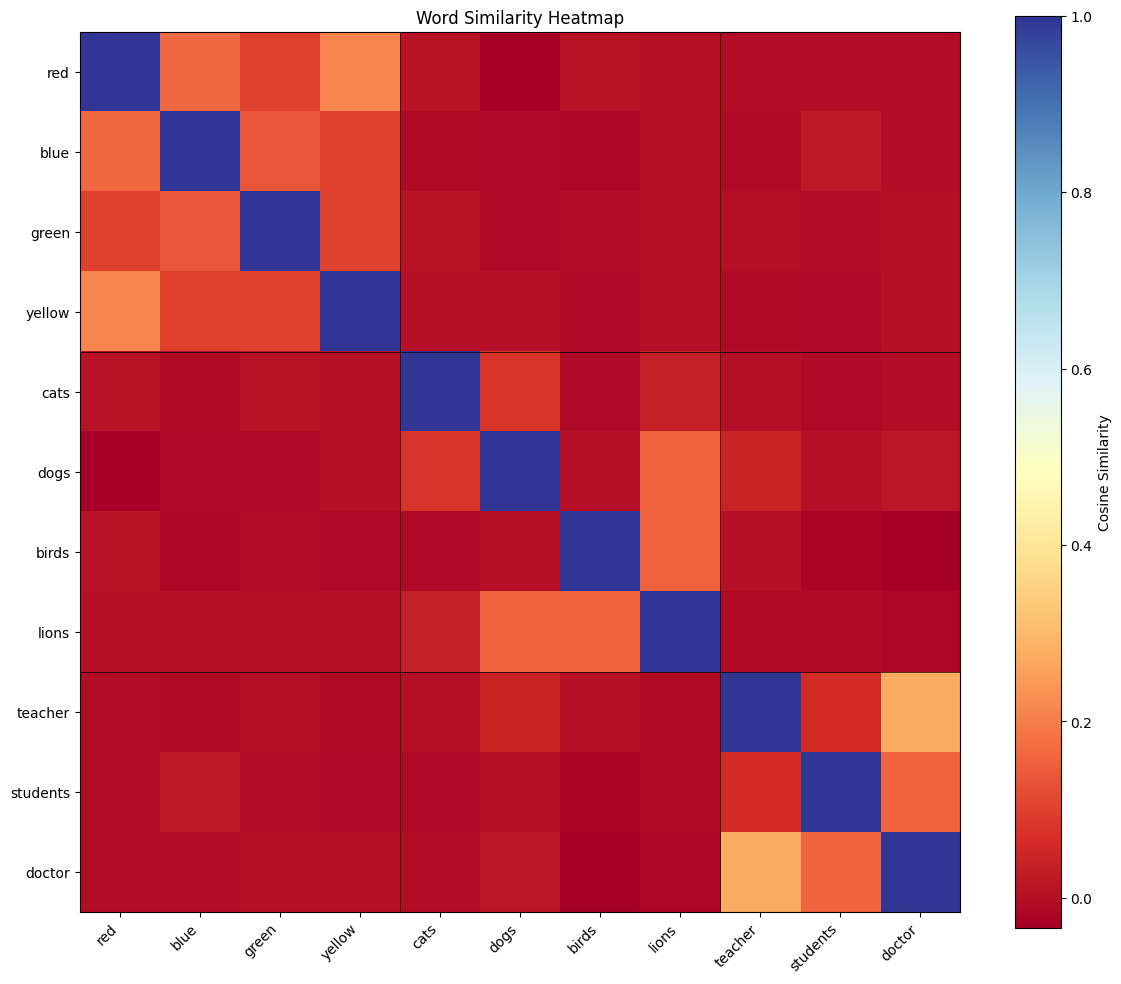

In [ ]:
# Create a heatmap of similarities
plt.figure(figsize=(12, 10))
similarity_matrix = np.zeros((len(all_words), len(all_words)))

for i, word1 in enumerate(all_words):
    for j, word2 in enumerate(all_words):
        similarity_matrix[i, j] = cosine_similarity(get_word_embedding(word1), get_word_embedding(word2))

plt.imshow(similarity_matrix, cmap='RdYlBu')
plt.colorbar(label='Cosine Similarity')

# Add word labels
plt.xticks(range(len(all_words)), all_words, rotation=45, ha='right')
plt.yticks(range(len(all_words)), all_words)

# Add gridlines to separate word categories
plt.axhline(y=len(color_words)-0.5, color='black', linestyle='-', linewidth=0.5)
plt.axhline(y=len(color_words)+len(animal_words)-0.5, color='black', linestyle='-', linewidth=0.5)
plt.axvline(x=len(color_words)-0.5, color='black', linestyle='-', linewidth=0.5)
plt.axvline(x=len(color_words)+len(animal_words)-0.5, color='black', linestyle='-', linewidth=0.5)

plt.title('Word Similarity Heatmap')
plt.tight_layout()
plt.show()

### 📊 Improved Heatmap with Enhanced Color Scale

The heatmap below uses the **`coolwarm`** color scale which is more intuitive:
- 🔴 **Red/Warm** = High similarity (words are semantically close)
- 🔵 **Blue/Cool** = Low or negative similarity (words are unrelated)
- **White** = Near-zero similarity

Each cell also shows the **exact similarity value**, making it easier to compare.
The thick black lines separate the three categories: Colors | Animals | People.

**Look for the pattern:** The 3×3 blocks along the diagonal (top-left, center, bottom-right) should appear **warmer** (more red) than the off-diagonal blocks, confirming the model learned to group words by category.

In [ ]:
# Create an improved heatmap with better color scale
fig, ax = plt.subplots(figsize=(12, 10))

similarity_matrix = np.zeros((len(all_words), len(all_words)))
for i, word1 in enumerate(all_words):
    for j, word2 in enumerate(all_words):
        similarity_matrix[i, j] = cosine_similarity(
            get_word_embedding(word1), get_word_embedding(word2)
        )

# Use 'coolwarm' colormap: blue for low similarity, red for high similarity
# This is much more intuitive than the default colormap
im = ax.imshow(similarity_matrix, cmap='coolwarm', vmin=-0.2, vmax=1.0, aspect='equal')

# Add colorbar with label
cbar = fig.colorbar(im, ax=ax, shrink=0.8, label='Cosine Similarity')

# Add word labels
ax.set_xticks(range(len(all_words)))
ax.set_xticklabels(all_words, rotation=45, ha='right', fontsize=12)
ax.set_yticks(range(len(all_words)))
ax.set_yticklabels(all_words, fontsize=12)

# Add similarity values as text annotations inside each cell
for i in range(len(all_words)):
    for j in range(len(all_words)):
        val = similarity_matrix[i, j]
        # Choose text color based on background
        text_color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, fontweight='bold', color=text_color)

# Add gridlines to separate word categories
ax.axhline(y=len(color_words)-0.5, color='black', linestyle='-', linewidth=2)
ax.axhline(y=len(color_words)+len(animal_words)-0.5, color='black', linestyle='-', linewidth=2)
ax.axvline(x=len(color_words)-0.5, color='black', linestyle='-', linewidth=2)
ax.axvline(x=len(color_words)+len(animal_words)-0.5, color='black', linestyle='-', linewidth=2)

# Add category labels
ax.text(-1.8, 1.5, '🎨 Colors', fontsize=11, fontweight='bold', va='center', rotation=90)
ax.text(-1.8, 5.5, '🐾 Animals', fontsize=11, fontweight='bold', va='center', rotation=90)
ax.text(-1.8, 8.5, '👤 People', fontsize=11, fontweight='bold', va='center', rotation=90)

ax.set_title('Word Similarity Heatmap (Cosine Similarity)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


---

## 🎓 Summary & Key Takeaways

In this notebook, we:

1. **Built a Word2Vec model from scratch** using PyTorch — just an embedding layer followed by a linear layer.
2. **Trained it** on a small corpus with three clear semantic categories (colors, animals, people).
3. **Visualized** the learned 50-dimensional embeddings in 2D using t-SNE, observing that similar words cluster together.
4. **Measured** word similarity using cosine similarity, confirming that within-category words are more similar than across-category words.

### 🔑 Key Concepts to Remember:

| Concept | Description |
|---------|-------------|
| **Distributional Hypothesis** | Words in similar contexts have similar meanings |
| **Word Embedding** | A dense vector representation of a word (e.g., 50 numbers) |
| **Skip-gram** | Predicts context words given a center word |
| **t-SNE** | Reduces high-dimensional data to 2D/3D for visualization |
| **Cosine Similarity** | Measures the angle between two vectors; range [-1, 1] |

### 🤔 Things to Explore Further:
- What happens if you change the `embedding_dim`? (Try 10 or 100)
- What if you increase the `window_size` in `generate_training_pairs`?
- Try training on a larger corpus — do the clusters become more distinct?
- Compare this simple model with pre-trained embeddings like GloVe or fastText.